In [12]:
import pandas as pd
import numpy as np
import datetime as dt

from statsmodels.tsa.api import STLForecast
from statsmodels.tsa.arima.model import ARIMA

import matplotlib.pyplot as plt

In [13]:
df_fall = pd.read_csv("data.csv")
power = np.array(df_fall["power"])

In [28]:
len(power)

77952

In [48]:
from sktime.forecasting.statsforecast import StatsForecastMSTL

# Define the index for splitting the data
split_index = 71423

# Split the data into training and testing sets
train_data = power[:split_index]
test_data = power[split_index:]

model = StatsForecastMSTL(season_length=[96,96*7]) 
fitted_model = model.fit(y=power) 
y_pred = fitted_model.predict(fh=range(1, 17)) 

In [58]:
len(test_data)

6529

In [60]:
import numpy as np
import pandas as pd
from sktime.forecasting.statsforecast import StatsForecastMSTL

# Assuming `power` is your time series data

# Define the index for splitting the data
split_index = 71423

# Split the data into training and testing sets
train_data = power[:split_index]
test_data = power[split_index:]

# Define the forecasting horizon
forecast_steps = len(test_data)  # Total steps to forecast
forecast_horizon = 16  # Steps to forecast at a time

# Define the model
model = StatsForecastMSTL(season_length=[96, 96*7])  # Assuming multiple seasonalities of 96 and 7 days

# Fit the initial model
fitted_model = model.fit(train_data)

# Initialize a list to store forecasted values
forecasted_values = []

# Iterate over forecast_steps in steps of forecast_horizon
for i in range(0, 6513, forecast_horizon):
    # Define the forecasting horizon for the current iteration
    fh = np.arange(1, 17)
    
    # Forecast next 16 steps and update the fitted model
    y_pred = fitted_model.fit_predict(fh=fh, y=test_data[i:i + forecast_horizon])
    
    # Append forecasted values
    forecasted_values.extend(y_pred)

In [78]:
len(forecasted_values)

6528

In [79]:
len(test_data)

6525

In [77]:
alpha = 0.2

test_data = test_data[1:]

# forecasted_values = [f[0] for f in forecasted_values]

mse = mean_squared_error(forecasted_values, test_data)

weights = alpha ** (1 + np.sign(forecasted_values, test_data))
wmse = mean_squared_error(forecasted_values, test_data, sample_weight=weights)



ValueError: Found input variables with inconsistent numbers of samples: [6528, 6525]

In [80]:
import numpy as np
import pandas as pd
from statsmodels.tsa.api import STLForecast
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

# Assuming `power` is your time series data

# Define the index for splitting the data
split_index = 71423

# Split the data into training and testing sets
train_data = power[:split_index]
test_data = power[split_index:]

# Iterate over different combinations of p, d, and q
for p in range(3):
    for d in range(2):
        for q in range(3):
            # Initialize STLForecast model for each combination of p, d, and q
            stlf = STLForecast(train_data, ARIMA, model_kwargs={"order": (p, d, q)}, period=96)
            result = stlf.fit()

            # Initialize the forecasted values list
            forecasted_values = []

            # Forecast future values using STLForecast on the testing data
            forecast_steps = len(test_data)  # Forecast the same number of steps as the length of the test data
            for _ in range(forecast_steps // 16):  # Dividing by 16 to forecast 16 steps at a time
                # Forecast next 16 steps
                forecast = result.forecast(steps=16)

                # Update the training data with the actual values from the test data
                train_data = np.append(train_data, test_data[:16])
                test_data = test_data[16:]

                # Re-fit STLForecast model with the updated training data
                stlf = STLForecast(train_data, ARIMA, model_kwargs={"order": (p, d, q)}, period=96)
                result = stlf.fit()

                forecasted_values.extend(forecast)

            # Calculate Mean Squared Error
            mse = mean_squared_error(power[split_index:], forecasted_values)

            print(f'p={p}, d={d}, q={q}. MSE = {mse}')


KeyboardInterrupt: 

In [17]:
import itertools

LOOKAHEAD = 16
TIMESTEPS_PER_DAY = 96

p = range(0, 3)
d = range(0, 2)
q = range(0, 3) 

pdq = list(itertools.product(p, d, q))
num_days_train = 20

for p, d, q in pdq:
    all_forecasts = []
    all_actual = []
    for i in range(LOOKAHEAD, len(power), LOOKAHEAD):
        train = power[i-LOOKAHEAD:i]
        test = power[i:i + LOOKAHEAD]
    
        stlf = STLForecast(train, ARIMA, model_kwargs={"order": (p, d, q)}, period=96)
        res = stlf.fit()
        forecast = res.forecast(LOOKAHEAD)
    
        all_forecasts.extend(forecast)
        all_actual.extend(test)
    
    
    all_forecasts = [x if x >= 0 else 0 for x in all_forecasts]

    print("------------------------------------------------")
    print(f"Training p={p}, d={d} and q={q}.")
    print(f"MSE = {mean_squared_error(all_forecasts, all_actual)}")
    weights = alpha ** (1 + np.sign(all_forecasts - power[2880:]))
    print(f"WMSE = {mean_squared_error(all_forecasts, all_actual, sample_weight=weights)}")

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.wa

KeyboardInterrupt: 

In [25]:
import itertools

p = range(0, 16, 4)
d = range(0, 1)
q = range(0, 16, 4)

pdq = list(itertools.product(p, d, q))
num_days_train = 20

for p, d, q in pdq:
    all_forecasts = []
    all_actual = []
    for i in range(2880, len(power), LOOKAHEAD):
        train = power[i-num_days_train*TIMESTEPS_PER_DAY:i - LOOKAHEAD]
        test = power[i-LOOKAHEAD:i]
    
        stlf = STLForecast(train, ARIMA, model_kwargs={"order": (p, d, q)}, period=96)
        res = stlf.fit()
        forecast = res.forecast(LOOKAHEAD)
    
        all_forecasts.extend(forecast)
        all_actual.extend(test)
    
    
    all_forecasts = [x if x >= 0 else 0 for x in all_forecasts]

    print("------------------------------------------------")
    print(f"Training p={p}, d={d} and q={q}.")
    print(f"MSE = {mean_squared_error(all_forecasts, all_actual)}")
    weights = alpha ** (1 + np.sign(all_forecasts - power[2880:]))
    print(f"WMSE = {mean_squared_error(all_forecasts, all_actual, sample_weight=weights)}")

------------------------------------------------
Training p=0, d=0 and q=0.
MSE = 48.169054834640704
WMSE = 40.489986616201485
------------------------------------------------
Training p=0, d=0 and q=4.
MSE = 44.788155248962475
WMSE = 36.70117885509293
------------------------------------------------
Training p=0, d=0 and q=8.
MSE = 42.379503685956124
WMSE = 32.5372725512214
------------------------------------------------
Training p=0, d=0 and q=12.
MSE = 40.65254508945863
WMSE = 31.7354582334456
------------------------------------------------
Training p=4, d=0 and q=0.
MSE = 38.56051688695329
WMSE = 31.47365208595414


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to conver

------------------------------------------------
Training p=4, d=0 and q=4.
MSE = 39.00020927509028
WMSE = 32.57017185080423


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.wa

KeyboardInterrupt: 

In [27]:
all_forecasts = []
all_actual = []
for i in range(2880, len(power), LOOKAHEAD):
    train = power[i-num_days_train*TIMESTEPS_PER_DAY:i - LOOKAHEAD]
    test = power[i-LOOKAHEAD:i]

    stlf = STLForecast(train, ARIMA, model_kwargs={"order": (1, 0, 2)}, period=96)
    res = stlf.fit()
    forecast = res.forecast(LOOKAHEAD)

    all_forecasts.extend(forecast)
    all_actual.extend(test)


all_forecasts = [x if x >= 0 else 0 for x in all_forecasts]

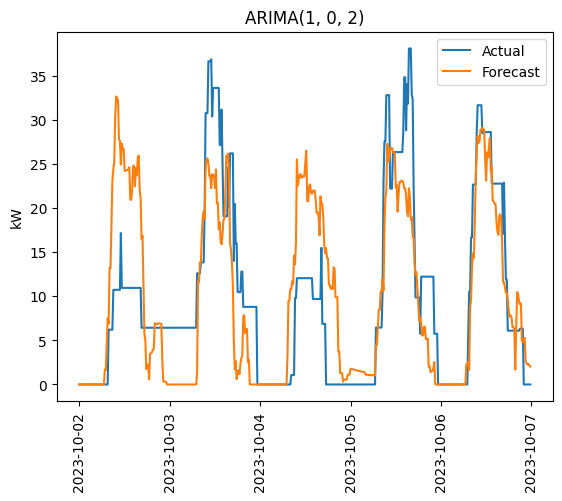

In [51]:
dates = pd.date_range(start='2023-10-02', periods=96*5, freq='15min')

plt.plot(dates, power[2400:2400 + 96*5], label="Actual")
plt.plot(dates, all_forecasts[16:96*5+16], label="Forecast")
plt.xticks(rotation=90)
plt.ylabel("kW")
plt.title("ARIMA(1, 0, 2)")
plt.legend();

In [66]:
96*5*5

2400

In [67]:
len(power[2400 - 16:-16])

3360

In [68]:
len(all_forecasts)

2880

In [69]:
test = power[2880 - 16:-16]

print(f"MSE:", mean_squared_error(test, all_forecasts))
weights = alpha ** (1 + np.sign(all_forecasts - test))
print(f"WMSE:", mean_squared_error(test, all_forecasts, sample_weight=weights))

MSE: 38.601531610880926
WMSE: 49.65461524310789
